In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process import GaussianProcessRegressor

# Generating Data

In [7]:
x = np.linspace(0, 10, 100)
y = np.linspace(-1, 1, 100)

X, Y = np.meshgrid(x, y)
Z = np.sin(X) * Y**2 / 10

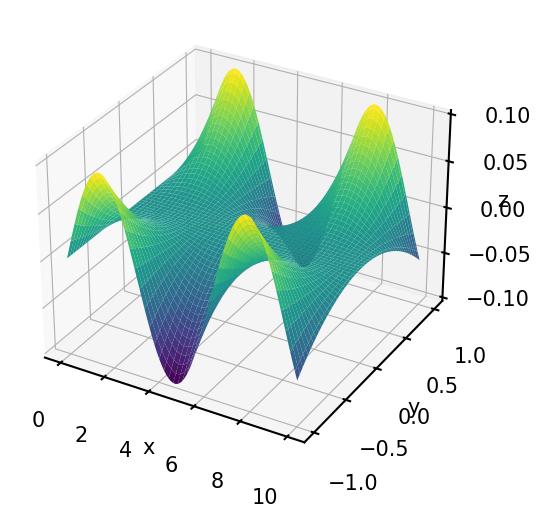

In [8]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()

In [49]:
def pre_process_data(arr):
    mean = np.mean(arr)
    std = np.std(arr)

    return (arr - mean) / std, {'mean': mean, 'std': std}

def undo_preprocessing(arr, p):
    return arr * p['std'] + p['mean']

In [106]:
x_pre_processed, params  = pre_process_data(x)

X, Y = np.meshgrid(x_pre_processed, y)

In [107]:
np.random.seed(42)

points = np.column_stack([X.ravel(), Y.ravel()])
values = Z.ravel()

idx = np.random.choice(len(points), 500, replace=False)

X_train = points[idx]
z_train = values[idx]

In [108]:
kernel = 1.0 * RBF(length_scale=[1.0, 0.2], length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10)

gp.fit(X_train, z_train)

/home/qubit/miniconda3/envs/igwn-py310/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:629: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=[1, 0.2]),
                         n_restarts_optimizer=10, normalize_y=True)

In [109]:
X_pred = np.column_stack([X.ravel(), Y.ravel()])

mean, std = gp.predict(X_pred, return_std=True) 

Z_mean = mean.reshape(X.shape)
Z_std = std.reshape(X.shape)

/home/qubit/miniconda3/envs/igwn-py310/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:445: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(


In [110]:
Z_mean = undo_preprocessing(Z_mean, params)

X_train[:, 0] = undo_preprocessing(X_train[:, 0], params)

z_train = undo_preprocessing(z_train, params)

X = undo_preprocessing(X, params)

Z_std = undo_preprocessing(Z_std, params)

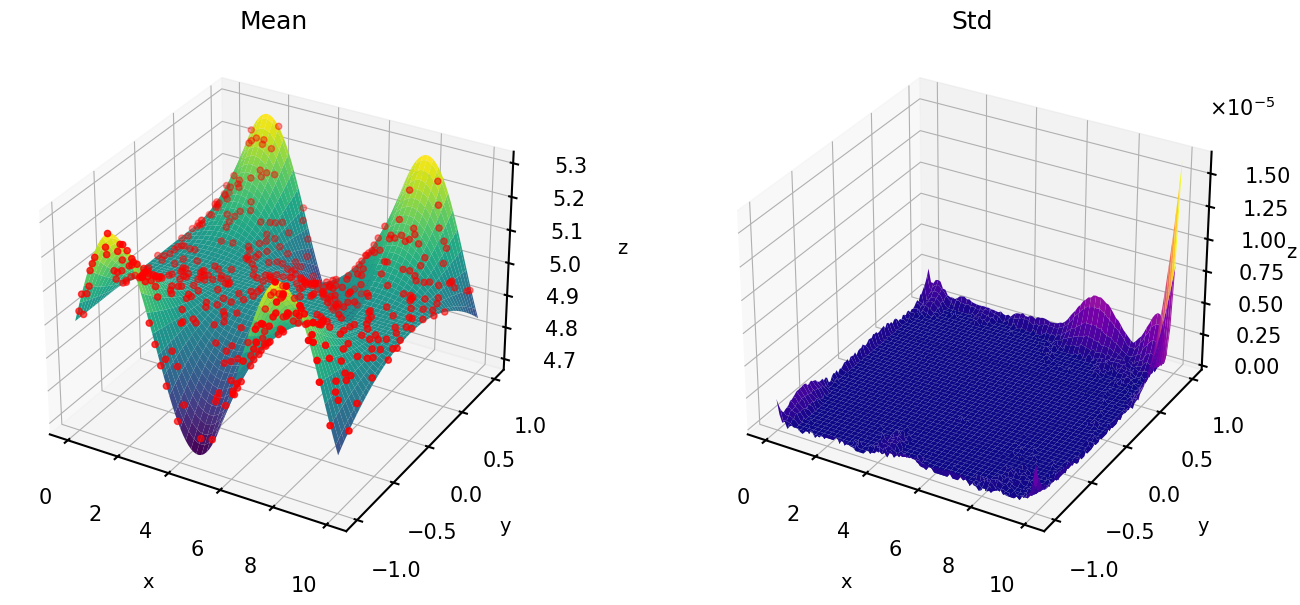

In [168]:
fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z_mean, cmap='viridis')
ax1.scatter(X_train[:, 0], X_train[:, 1], z_train, color='r', s=20)
ax1.set_title('Mean')
ax1.set_xlabel('x', fontsize=14, labelpad=30)
ax1.set_ylabel('y', fontsize=14, labelpad=30)
ax1.set_zlabel('z', fontsize=14, labelpad=30)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z_std, cmap='plasma')
ax2.set_title('Std')
ax2.zaxis.get_offset_text().set_visible(False)
ax2.text2D(0.95, 0.85, r"$\times 10^{-5}$", transform=ax2.transAxes, fontsize=15)
ax2.set_xlabel('x', fontsize=14, labelpad=30)
ax2.set_ylabel('y', fontsize=14, labelpad=30)
ax2.set_zlabel('z', fontsize=14, labelpad=17)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

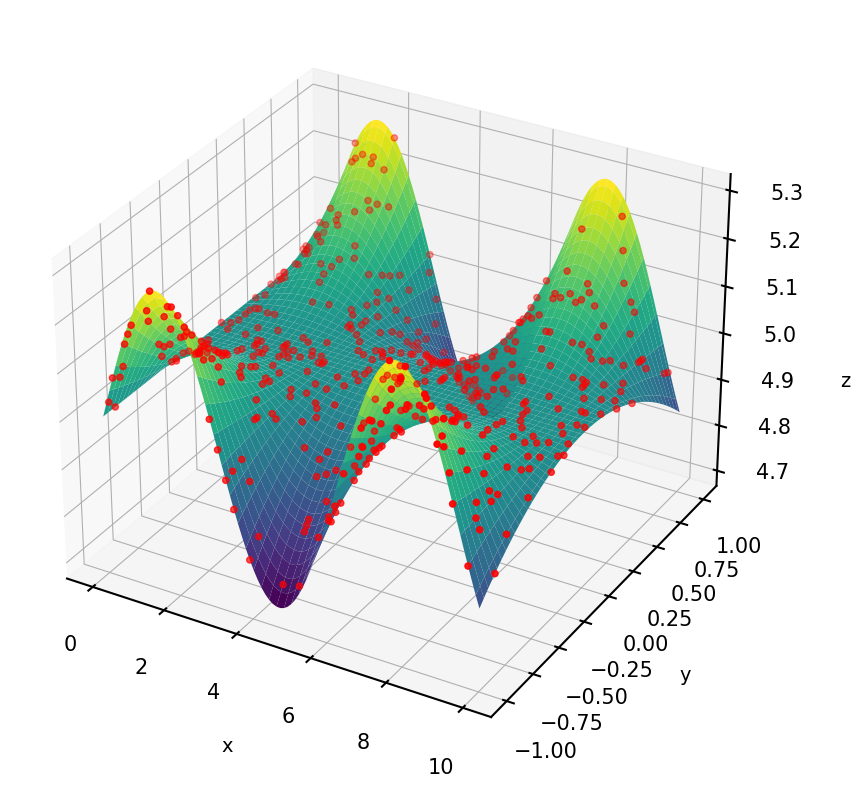

In [170]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z_mean, cmap='viridis')
ax.scatter(X_train[:, 0], X_train[:, 1], z_train, color='r', s=20)

ax.set_xlabel('x', fontsize=14, labelpad=30)
ax.set_ylabel('y', fontsize=14, labelpad=30)
ax.set_zlabel('')
ax.text2D(1.1, 0.5, 'z', transform=ax.transAxes,
          rotation=0, fontsize=14)

plt.tight_layout()
plt.show()

# Spline Fit

In [85]:
sorting_idx = np.argsort(np.squeeze(x_train))
x_train_sorted = np.squeeze(x_train)[sorting_idx]
y_train_sorted = np.squeeze(y_train)[sorting_idx]

In [86]:
spline = CubicSpline(x_train_sorted, y_train_sorted)

In [88]:
y_pred_spline = spline(x)

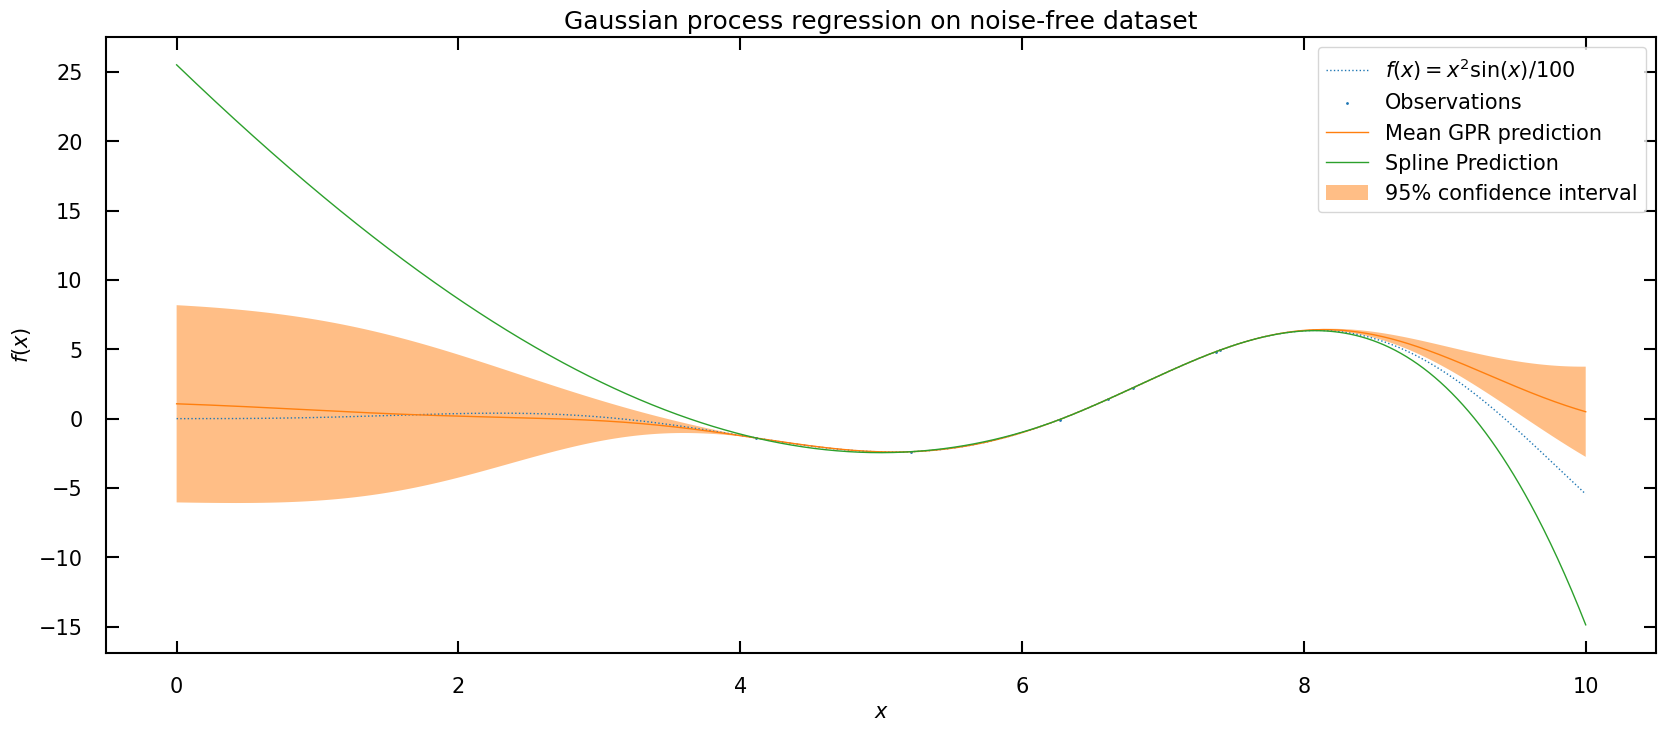

In [94]:
plt.figure(figsize=(20, 8))
plt.plot(x, y, label=r"$f(x) = x^2 \sin(x) / 100$", linestyle="dotted")
plt.scatter(x_train, y_train, label="Observations")
plt.plot(x, mean_prediction, label="Mean GPR prediction")
plt.plot(x, y_pred_spline, label='Spline Prediction')
plt.fill_between(
    x.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")